In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('dataset/babies.csv')
df.head()

,bwt,gestation,parity,age,height,weight,smoke
0,120,284,0,27,62,100,0
1,113,282,0,33,64,135,0
2,128,279,0,28,64,115,1
3,123,999,0,36,69,190,0
4,108,282,0,23,67,125,1


In [3]:
df.info()    

<class 'pandas.DataFrame'>
RangeIndex: 1236 entries, 0 to 1235
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   bwt        1236 non-null   int64
 1   gestation  1236 non-null   int64
 2   parity     1236 non-null   int64
 3   age        1236 non-null   int64
 4   height     1236 non-null   int64
 5   weight     1236 non-null   int64
 6   smoke      1236 non-null   int64
dtypes: int64(7)
memory usage: 67.7 KB


In [4]:
df.describe()

,bwt,gestation,parity,age,height,weight,smoke
count,1236.000000,1236.000000,1236.000000,1236.000000,1236.000000,1236.000000,1236.000000
mean,119.576861,286.907767,0.254854,27.371359,64.669903,153.976537,0.464401
std,18.236452,75.156870,0.435956,6.456992,5.261065,147.872525,0.912102
min,55.000000,148.000000,0.000000,15.000000,53.000000,87.000000,0.000000
25%,108.750000,272.000000,0.000000,23.000000,62.000000,115.000000,0.000000
50%,120.000000,280.000000,0.000000,26.000000,64.000000,126.000000,0.000000
75%,131.000000,288.000000,1.000000,31.000000,66.000000,140.000000,1.000000
max,176.000000,999.000000,1.000000,99.000000,99.000000,999.000000,9.000000


In [5]:
#data cleaning
#duplicate value handling and missing value handling
#finding missing values
df.isnull().sum()



bwt          0
gestation    0
parity       0
age          0
height       0
weight       0
smoke        0
dtype: int64

In [6]:
#removeing missing values
df.dropna(inplace=True)
df.isnull().sum()

bwt          0
gestation    0
parity       0
age          0
height       0
weight       0
smoke        0
dtype: int64

In [7]:
##duplicate value
print(df.duplicated().sum())

0


In [8]:
#explortory data analysis
import matplotlib.pyplot as plt


In [9]:
df.columns

Index(['bwt', 'gestation', 'parity', 'age', 'height', 'weight', 'smoke'], dtype='str')

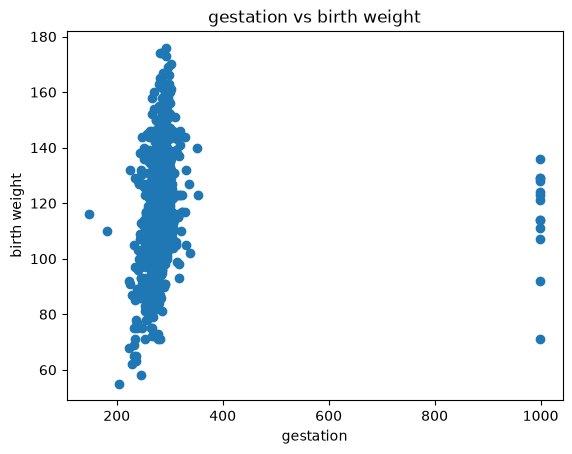

In [10]:
plt.scatter(df['gestation'],df['bwt'])
plt.xlabel('gestation')
plt.ylabel('birth weight')
plt.title('gestation vs birth weight')
plt.show()

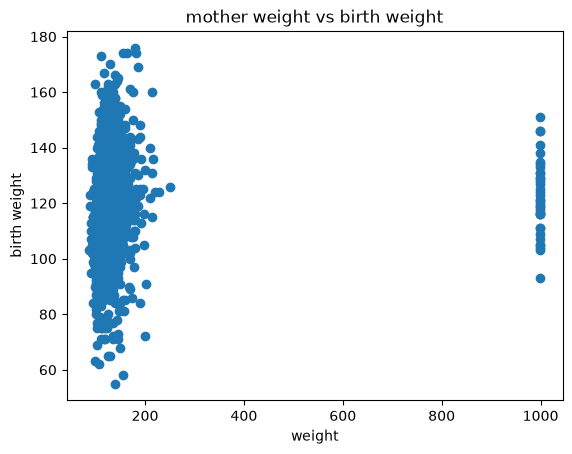

In [11]:
plt.scatter(df['weight'],df['bwt'])
plt.xlabel('weight')
plt.ylabel('birth weight')
plt.title('mother weight vs birth weight')
plt.show()

In [12]:
df['smoke'].unique()

array([0, 1, 9])

In [13]:
df['smoke'].value_counts()

smoke
0    742
1    484
9     10
Name: count, dtype: int64

In [14]:
df['smoke'].value_counts(normalize=True)*100

smoke
0    60.032362
1    39.158576
9     0.809061
Name: proportion, dtype: float64

In [15]:
df['parity'].unique()

array([0, 1])

In [16]:
df['parity'].value_counts()

parity
0    921
1    315
Name: count, dtype: int64

In [17]:
##correlation matrix
df.corr()

,bwt,gestation,parity,age,height,weight,smoke
bwt,1.000000,0.062504,-0.046107,0.029041,0.125541,0.046764,-0.097609
gestation,0.062504,1.000000,-0.008475,-0.003265,0.065981,0.049459,-0.021770
parity,-0.046107,-0.008475,1.000000,-0.298859,-0.015540,-0.069002,-0.051491
age,0.029041,-0.003265,-0.298859,1.000000,0.048518,0.062732,0.000940
height,0.125541,0.065981,-0.015540,0.048518,1.000000,0.601003,0.023704
weight,0.046764,0.049459,-0.069002,0.062732,0.601003,1.000000,0.012604
smoke,-0.097609,-0.021770,-0.051491,0.000940,0.023704,0.012604,1.000000


In [18]:
#splitting dataset inti x  and y

y=df['bwt']


In [19]:
x=df.iloc[:,1:]
x.head()

,gestation,parity,age,height,weight,smoke
0,284,0,27,62,100,0
1,282,0,33,64,135,0
2,279,0,28,64,115,1
3,999,0,36,69,190,0
4,282,0,23,67,125,1


In [20]:
#train test split
##command to install sickit-learn :- pip install sickit-learn>

from sklearn.model_selection import train_test_split as tts

In [21]:
x_train, x_test, y_train, y_test=tts(x,y,test_size=0.20,)

In [22]:
x_train.shape

(988, 6)

In [23]:
x_test.shape

(248, 6)

In [24]:
###buliding machine learning model

from sklearn.linear_model import LinearRegression, Lasso, Ridge


In [25]:
lr= LinearRegression()
lasso = Lasso()
ridge= Ridge()

In [26]:
lr.fit(x_train, y_train,)
lasso.fit(x_train, y_train,)
ridge.fit(x_train, y_train,)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [27]:
lr_pre=lr.predict(x_test)
las_pre=lasso.predict(x_test)
rid_pre=ridge.predict(x_test)

In [33]:
from sklearn.metrics import r2_score, mean_squared_error

In [35]:
lr_rscore=r2_score(y_test, lr_pre)
lasso_rscore=r2_score(y_test, las_pre)
ridge_rscore=r2_score(y_test, rid_pre)

In [31]:
lr_mse=mean_squared_error(y_test, lr_pre)
lasso_mse=mean_squared_error(y_test, las_pre)
ridge_mse=mean_squared_error(y_test, rid_pre)

In [36]:
print("\n performance of linear regression model is as follows:")
print("R2 Score :",lr_rscore)
print("Mean Squared Error :",lr_mse)


print("\n performance of lasso regression model is as follows:")
print("R2 Score :",lasso_rscore)
print("Mean Squared Error :",lasso_mse)


print("\n performance of ridge regression model is as follows:")
print("R2 Score :",ridge_rscore)
print("Mean Squared Error :",ridge_mse)


 performance of linear regression model is as follows:
R2 Score : 0.03512123416849455
Mean Squared Error : 346.2855511168661

 performance of lasso regression model is as follows:
R2 Score : 0.029438537079968574
Mean Squared Error : 348.3250155167637

 performance of ridge regression model is as follows:
R2 Score : 0.03514927595205619
Mean Squared Error : 346.27548719503596


In [34]:
print(type(lr_score))
print(type(lr_mse))

print("lr_score =", lr_score)
print("lr_mse =", lr_mse)

<class 'float'>
<class 'float'>
lr_score = 346.2855511168661
lr_mse = 346.2855511168661


In [ ]:
#Selected model is linear regression model as it has high R2 score and low mean squared error
#storing it into pickel format
#pickel is used to store the model in binary format so that it can be used later for prediction without training the model again.


In [37]:
import pickle


In [38]:
with open("model/model.pkl","wb") as f:
    pickle.dump(lr,f)
